In [2]:
import pyspark.sql.functions as f
import pyspark.sql.types as t
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio

from gentropy.common.session import Session

pio.renderers.default = "vscode"

Loading BokehJS ...

/Users/dc16/gentropy/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [5]:
session = Session(extended_spark_conf={"spark.driver.memory": "13g"})

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/08/27 16:11:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [21]:
target = session.spark.read.parquet("/users/dc16/downloads/target")
l2g = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS.parquet"
)
cred_sets = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_credible_sets",
    # '/users/dc16/data/releases/25.06/credible_set/'
)
studies = (
    session.spark.read.parquet("/users/dc16/data/gentropy_paper/gwas_therapeutic_areas")
    .filter(~f.col("measurement"))
    .filter(f.col("binaryLessCases"))
    .drop("geneId")
)
tissue_specificity = session.spark.read.parquet("/users/dc16/data/releases/25.06/target_prioritisation").select(
    "targetId", "tissueSpecificity", "tissueDistribution"
)
qualified_studies = session.spark.read.parquet("/users/dc16/data/gentropy_paper/qualifying_studies").select("studyId")

In [38]:
studies.count()

17788

In [39]:
studies.join(qualified_studies, "studyId", "semi").count()

15730

In [40]:
l2g_signif = (
    l2g.join(
        cred_sets.select(
            "studyLocusId",
            "studyId",
        ),
        "studyLocusId",
        "inner",
    )
    .join(studies, "studyId", "inner")
    .join(qualified_studies, "studyId", "semi")
    .withColumn(
        "publicationDate",
        f.when(f.col("studyId").startswith("FINNGEN"), "2023-01-18").otherwise(f.col("publicationDate")),
    )
    .withColumn(
        "effectiveSampleSize",
        (f.lit(4.0) * f.col("nCases") * f.col("nControls")) / (f.col("nCases") + f.col("nControls")),
    )
)

In [41]:
l2g_signif.count()

70400

In [42]:
(
    l2g_signif.agg(
        f.size(f.array_distinct(f.flatten(f.collect_list("diseaseIds")))).alias("uniqueDiseases"),
        f.size(f.array_distinct(f.flatten(f.collect_list("mappedTherapeuticAreas")))).alias("uniqueTherapeuticAreas"),
        f.sum("cancerOrBenignTumor").alias("cancerOrBenignTumor"),
        f.sum("infectiousDisease").alias("infectiousDisease"),
        f.sum("pregnancyOrPerinatalDisease").alias("pregnancyOrPerinatalDisease"),
        f.sum("disorderOfVisualSystem").alias("disorderOfVisualSystem"),
        f.sum("cardiovascularDisease").alias("cardiovascularDisease"),
        f.sum("pancreasDisease").alias("pancreasDisease"),
        f.sum("gastrointestinalDisease").alias("gastrointestinalDisease"),
        f.sum("reproductiveSystemOrBreastDisease").alias("reproductiveSystemOrBreastDisease"),
        f.sum("integumentarySystemDisease").alias("integumentarySystemDisease"),
        f.sum("endocrineSystemDisease").alias("endocrineSystemDisease"),
        f.sum("respiratoryOrThoracicDisease").alias("respiratoryOrThoracicDisease"),
        f.sum("urinarySystemDisease").alias("urinarySystemDisease"),
        f.sum("musculoskeletalOrConnectiveTissueDisease").alias("musculoskeletalOrConnectiveTissueDisease"),
        f.sum("disorderOfEar").alias("disorderOfEar"),
        f.sum("immuneSystemDisease").alias("immuneSystemDisease"),
        f.sum("hematologicDisease").alias("hematologicDisease"),
        f.sum("nervousSystemDisease").alias("nervousSystemDisease"),
        f.sum("psychiatricDisorder").alias("psychiatricDisorder"),
        f.sum("nutritionalOrMetabolicDisease").alias("nutritionalOrMetabolicDisease"),
        f.sum("geneticFamilialOrCongenitalDisease").alias("geneticFamilialOrCongenitalDisease"),
        f.sum("injuryPoisoningOrOtherComplication").alias("injuryPoisoningOrOtherComplication"),
        f.sum("signOrSymptom").alias("signOrSymptom"),
        f.sum("other").alias("other"),
    ).show(vertical=True)
)

-RECORD 0-----------------------------------------
 uniqueDiseases                           | 1394  
 uniqueTherapeuticAreas                   | 23    
 cancerOrBenignTumor                      | 10916 
 infectiousDisease                        | 1045  
 pregnancyOrPerinatalDisease              | 183   
 disorderOfVisualSystem                   | 3059  
 cardiovascularDisease                    | 10297 
 pancreasDisease                          | 6271  
 gastrointestinalDisease                  | 1573  
 reproductiveSystemOrBreastDisease        | 638   
 integumentarySystemDisease               | 1381  
 endocrineSystemDisease                   | 1905  
 respiratoryOrThoracicDisease             | 4253  
 urinarySystemDisease                     | 1697  
 musculoskeletalOrConnectiveTissueDisease | 6338  
 disorderOfEar                            | 70    
 immuneSystemDisease                      | 1110  
 hematologicDisease                       | 247   
 nervousSystemDisease          

In [43]:
l2g_signif.show()

+--------------------+--------------------+---------------+-------------------+----------+----------+---+-----------+-----------+---------+--------------------+------------------------+---------------------+--------+--------------------+----------------------+---------------+------------------+----------------------------------+--------------------+------+---------+--------+--------------------+---------------------+--------------------+--------------------+--------------------+-------------+--------------------+-----------+---------+--------------------+--------------------+--------------------+-----------+----------------------+-----------+---------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+--------

In [44]:
genes_therapeutic_areas = (
    l2g_signif.groupBy("geneId")
    .agg(
        f.size(f.array_distinct(f.flatten(f.collect_list("diseaseIds")))).alias("uniqueDiseases"),
        f.size(f.array_distinct(f.flatten(f.collect_list("mappedTherapeuticAreas")))).alias("uniqueTherapeuticAreas"),
        f.max("eQTL_coloc").alias("maxEQTLColoc"),
        f.max("pQTL_coloc").alias("maxPQTLColoc"),
        f.max("VEP").alias("maxVEP"),
        f.max("distanceTSS").alias("maxDistanceTSS"),
        f.min(f.col("effectiveSampleSize")).alias("minEffectiveSampleSize"),
        f.max(f.col("effectiveSampleSize")).alias("maxEffectiveSampleSize"),
        f.min("publicationDate").alias("earliestPublicationDate"),
        f.sum("cancerOrBenignTumor").alias("cancerOrBenignTumor"),
        f.sum("infectiousDisease").alias("infectiousDisease"),
        f.sum("pregnancyOrPerinatalDisease").alias("pregnancyOrPerinatalDisease"),
        f.sum("disorderOfVisualSystem").alias("disorderOfVisualSystem"),
        f.sum("cardiovascularDisease").alias("cardiovascularDisease"),
        f.sum("pancreasDisease").alias("pancreasDisease"),
        f.sum("gastrointestinalDisease").alias("gastrointestinalDisease"),
        f.sum("reproductiveSystemOrBreastDisease").alias("reproductiveSystemOrBreastDisease"),
        f.sum("integumentarySystemDisease").alias("integumentarySystemDisease"),
        f.sum("endocrineSystemDisease").alias("endocrineSystemDisease"),
        f.sum("respiratoryOrThoracicDisease").alias("respiratoryOrThoracicDisease"),
        f.sum("urinarySystemDisease").alias("urinarySystemDisease"),
        f.sum("musculoskeletalOrConnectiveTissueDisease").alias("musculoskeletalOrConnectiveTissueDisease"),
        f.sum("disorderOfEar").alias("disorderOfEar"),
        f.sum("immuneSystemDisease").alias("immuneSystemDisease"),
        f.sum("hematologicDisease").alias("hematologicDisease"),
        f.sum("nervousSystemDisease").alias("nervousSystemDisease"),
        f.sum("psychiatricDisorder").alias("psychiatricDisorder"),
        f.sum("nutritionalOrMetabolicDisease").alias("nutritionalOrMetabolicDisease"),
        f.sum("geneticFamilialOrCongenitalDisease").alias("geneticFamilialOrCongenitalDisease"),
        f.sum("injuryPoisoningOrOtherComplication").alias("injuryPoisoningOrOtherComplication"),
        f.sum("signOrSymptom").alias("signOrSymptom"),
        f.sum("other").alias("other"),
    )
    .withColumn(
        "totalStudies",
        f.col("cancerOrBenignTumor")
        + f.col("infectiousDisease")
        + f.col("pregnancyOrPerinatalDisease")
        + f.col("disorderOfVisualSystem")
        + f.col("cardiovascularDisease")
        + f.col("pancreasDisease")
        + f.col("gastrointestinalDisease")
        + f.col("reproductiveSystemOrBreastDisease")
        + f.col("integumentarySystemDisease")
        + f.col("endocrineSystemDisease")
        + f.col("respiratoryOrThoracicDisease")
        + f.col("urinarySystemDisease")
        + f.col("musculoskeletalOrConnectiveTissueDisease")
        + f.col("disorderOfEar")
        + f.col("immuneSystemDisease")
        + f.col("hematologicDisease")
        + f.col("nervousSystemDisease")
        + f.col("psychiatricDisorder")
        + f.col("nutritionalOrMetabolicDisease")
        + f.col("geneticFamilialOrCongenitalDisease")
        + f.col("injuryPoisoningOrOtherComplication")
        + f.col("signOrSymptom")
        + f.col("other"),
    )
    .join(
        target.withColumns(
            {
                "lofConstraint": f.filter("constraint", lambda x: x.constraintType == "lof")[0]["oeUpper"],
                "misConstraint": f.filter("constraint", lambda x: x.constraintType == "mis")[0]["score"],
                "synConstraint": f.filter("constraint", lambda x: x.constraintType == "syn")[0]["score"],
            }
        ).select(
            "id",
            "approvedSymbol",
            "lofConstraint",
            "misConstraint",
            "synConstraint",
            f.size("pathways").alias("pathwayCount"),
        ),
        target["id"] == f.col("geneId"),
        "inner",
    )
    .withColumn("pathwayCount", f.when(f.col("pathwayCount") == -1, f.lit(0)).otherwise(f.col("pathwayCount")))
    .withColumn("lofConstraint", 1 - f.col("lofConstraint"))
    .drop(
        "id",
    )
    .join(tissue_specificity, f.col("targetId") == f.col("geneId"), "inner")
    .drop("targetId")
    .sort(f.desc("uniqueTherapeuticAreas"))
)

In [45]:
genes_therapeutic_areas.select("geneId").distinct().count()

8285

In [46]:
genes_therapeutic_areas.show()

+---------------+--------------+----------------------+------------+------------+------+--------------+----------------------+----------------------+-----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+------------+--------------+-------------+-------------+-------------+------------+-----------------+------------------+
|         geneId|uniqueDiseases|uniqueTherapeuticAreas|maxEQTLColoc|maxPQTLColoc|maxVEP|maxDistanceTSS|minEffectiveSampleSize|maxEffectiveSampleSize|earliestPublicati

In [47]:
genes_therapeutic_areas.write.parquet(
    "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/genes_therapeutic_areas",
    mode="overwrite",
)

In [6]:
genes_therapeutic_areas = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/genes_therapeutic_areas"
)

25/08/27 16:11:48 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-google-hadoop-file-system.properties,hadoop-metrics2.properties


In [49]:
print(
    "Number of protein-coding genes with constraint score assigned to a therapeutic area:",
    genes_therapeutic_areas.count(),
)
genes_therapeutic_areas.agg(f.mean("lofConstraint"), f.mean("misConstraint"), f.mean("synConstraint")).show()

Number of protein-coding genes with constraint score assigned to a therapeutic area: 8285
+-------------------+------------------+--------------------+
| avg(lofConstraint)|avg(misConstraint)|  avg(synConstraint)|
+-------------------+------------------+--------------------+
|0.09913803096902757|0.9707007541331112|-0.19891588666325663|
+-------------------+------------------+--------------------+



In [50]:
genes_not_assigned = (
    target.filter(~f.col("id").isin([row["geneId"] for row in genes_therapeutic_areas.select("geneId").collect()]))
    .filter(f.col("biotype") == "protein_coding")
    .withColumns(
        {
            "lofConstraint": f.filter("constraint", lambda x: x.constraintType == "lof")[0]["oeUpper"],
            "misConstraint": f.filter("constraint", lambda x: x.constraintType == "mis")[0]["score"],
            "synConstraint": f.filter("constraint", lambda x: x.constraintType == "syn")[0]["score"],
        }
    )
    .select(
        "id",
        "approvedSymbol",
        "lofConstraint",
        "misConstraint",
        "synConstraint",
    )
    .withColumn("lofConstraint", 1 - f.col("lofConstraint"))
)
print(
    "Number of protein-coding genes with a loss-of-function constraint score not assigned to a therapeutic area:",
    genes_not_assigned.count(),
)
genes_not_assigned.agg(f.mean("lofConstraint"), f.mean("misConstraint"), f.mean("synConstraint")).show()

Number of protein-coding genes with a loss-of-function constraint score not assigned to a therapeutic area: 11845
+--------------------+------------------+--------------------+
|  avg(lofConstraint)|avg(misConstraint)|  avg(synConstraint)|
+--------------------+------------------+--------------------+
|-0.07142654138065407|0.7430723788493306|-0.11982229532694447|
+--------------------+------------------+--------------------+



In [7]:
genes_pd = genes_therapeutic_areas.toPandas()

25/08/27 16:11:51 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [52]:
genes_pd

,geneId,uniqueDiseases,uniqueTherapeuticAreas,maxEQTLColoc,maxPQTLColoc,maxVEP,maxDistanceTSS,minEffectiveSampleSize,maxEffectiveSampleSize,earliestPublicationDate,...,signOrSymptom,other,totalStudies,approvedSymbol,lofConstraint,misConstraint,synConstraint,pathwayCount,tissueSpecificity,tissueDistribution
0,ENSG00000147883,148,21,1,0,0,1,1622.261017,1.424218e+06,2007-04-26,...,1,60,577,CDKN2B,-0.836,-1.21270,-0.25674,5,0.50,0.0
1,ENSG00000175164,105,20,1,1,1,1,1249.622344,1.424218e+06,2009-03-10,...,2,71,371,ABO,-0.416,0.14459,-0.36479,0,0.50,0.0
2,ENSG00000140718,126,19,1,0,0,1,1059.622642,1.470467e+06,2007-04-26,...,0,47,339,FTO,0.076,1.27140,1.05890,1,-1.00,-1.0
3,ENSG00000111252,87,17,1,1,1,1,5504.013052,7.564710e+05,2009-05-10,...,0,18,193,SH2B3,-0.350,-3.16080,-2.22350,3,0.50,-1.0
4,ENSG00000130203,107,16,1,1,1,1,613.779310,1.778690e+06,2013-04-04,...,4,76,354,APOE,-0.319,-1.13230,-1.05590,12,0.75,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8280,ENSG00000288867,1,1,0,0,0,1,155496.871408,2.054330e+05,2025-04-01,...,0,0,2,PPIAL4C,-0.835,1.21730,1.20090,0,0.50,0.5
8281,ENSG00000289710,1,1,0,0,0,1,286746.100275,4.338626e+05,2024-06-05,...,0,0,2,ENSG00000289710,NaN,NaN,NaN,0,NaN,NaN
8282,ENSG00000291315,1,1,0,0,0,0,376569.559706,3.765696e+05,2023-01-18,...,0,1,1,ENSG00000291315,NaN,NaN,NaN,0,1.00,0.5
8283,ENSG00000293137,1,1,0,0,0,0,292977.180692,2.929772e+05,2021-11-04,...,0,1,1,MSL3B,NaN,NaN,NaN,0,NaN,NaN


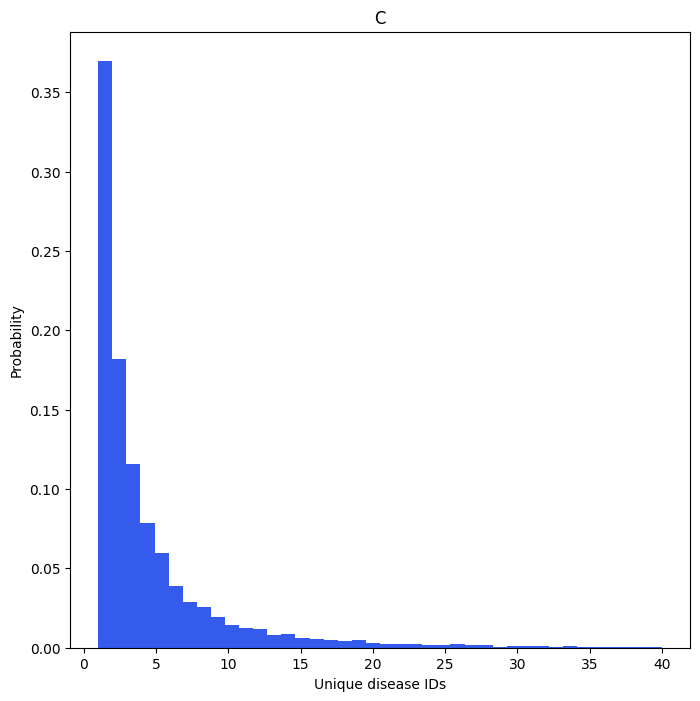

In [8]:
plt.figure(figsize=(8, 8))
plt.hist(
    genes_pd[genes_pd["uniqueDiseases"] <= 40]["uniqueDiseases"],
    density=True,
    color="#345BEB",
    bins=len(
        genes_pd[genes_pd["uniqueDiseases"] <= 40]["uniqueDiseases"].unique()
    ),  # Adjust bins for better visualization
)
plt.xlabel("Unique disease IDs")
plt.ylabel("Probability")
plt.title("C")
plt.show()

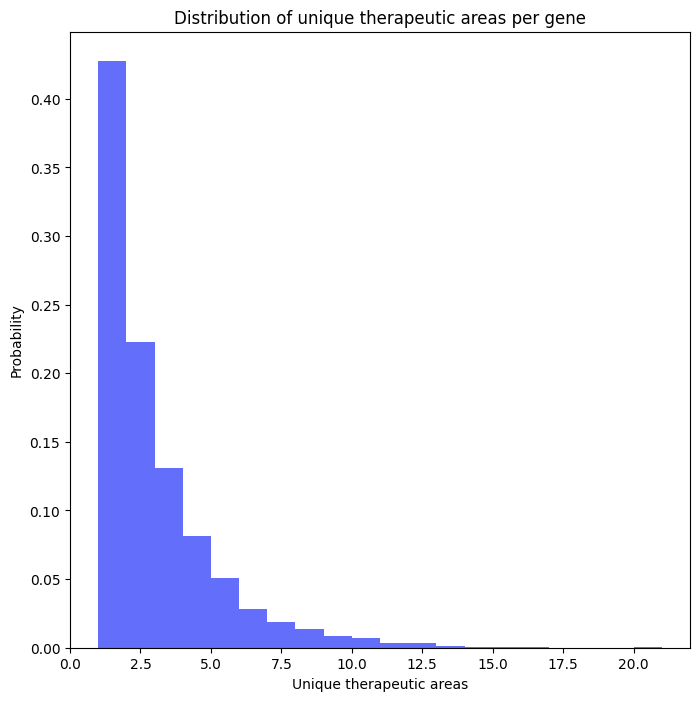

In [9]:
plt.figure(figsize=(8, 8))
plt.hist(
    genes_pd["uniqueTherapeuticAreas"],
    density=True,
    color="#636EFA",
    bins=len(genes_pd["uniqueTherapeuticAreas"].unique()),
)
plt.xlabel("Unique therapeutic areas")
plt.ylabel("Probability")
plt.title("Distribution of unique therapeutic areas per gene")
plt.show()

In [55]:
print("Number with more than one:", len(genes_pd[genes_pd["uniqueTherapeuticAreas"] > 1]))
print("Percentage with more than 1:", len(genes_pd[genes_pd["uniqueTherapeuticAreas"] > 1]) / len(genes_pd))
print("Mean:", genes_pd["uniqueTherapeuticAreas"].mean())
print("Median:", genes_pd["uniqueTherapeuticAreas"].median())
print("Max:", genes_pd["uniqueTherapeuticAreas"].max())
print("Standard Deviation:", genes_pd["uniqueTherapeuticAreas"].std())

Number with more than one: 4743
Percentage with more than 1: 0.5724803862401932
Mean: 2.5308388654194327
Median: 2.0
Max: 21
Standard Deviation: 2.124145826846405


In [56]:
print("Number with more than one:", len(genes_pd[genes_pd["uniqueDiseases"] > 1]))
print("Percentage with more than 1:", len(genes_pd[genes_pd["uniqueDiseases"] > 1]) / len(genes_pd))
print("Mean:", genes_pd["uniqueDiseases"].mean())
print("Median:", genes_pd["uniqueDiseases"].median())
print("Max:", genes_pd["uniqueDiseases"].max())
print("Standard Deviation:", genes_pd["uniqueDiseases"].std())

Number with more than one: 5314
Percentage with more than 1: 0.6414001207000604
Mean: 4.448762824381412
Median: 2.0
Max: 148
Standard Deviation: 6.635319325896013


In [57]:
len(genes_pd[genes_pd["uniqueDiseases"] > 2]) / len(genes_pd)

0.4651780325890163

In [58]:
print("Min:", genes_pd["lofConstraint"].min())
print("Mean:", genes_pd["lofConstraint"].mean())
print("Median:", genes_pd["lofConstraint"].median())
print("Max:", genes_pd["lofConstraint"].max())

Min: -0.998
Mean: 0.09913804
Median: 0.12900001
Max: 0.96


In [59]:
genes_pd["uniqueTherapeuticAreas"].corr(
    genes_pd["uniqueDiseases"]
)  # This is higher than previous 'pleiotropy' score correlation - 0.75

0.8448537314709607

In [60]:
genes_pd[
    [
        "geneId",
        "approvedSymbol",
        "uniqueDiseases",
        "uniqueTherapeuticAreas",
        "maxEQTLColoc",
        "maxPQTLColoc",
        "maxVEP",
        "maxDistanceTSS",
        "minEffectiveSampleSize",
        "maxEffectiveSampleSize",
        "earliestPublicationDate",
        "lofConstraint",
        "misConstraint",
        "synConstraint",
        "pathwayCount",
        "tissueSpecificity",
        "tissueDistribution",
    ]
][0:10]

,geneId,approvedSymbol,uniqueDiseases,uniqueTherapeuticAreas,maxEQTLColoc,maxPQTLColoc,maxVEP,maxDistanceTSS,minEffectiveSampleSize,maxEffectiveSampleSize,earliestPublicationDate,lofConstraint,misConstraint,synConstraint,pathwayCount,tissueSpecificity,tissueDistribution
0,ENSG00000147883,CDKN2B,148,21,1,0,0,1,1622.261017,1.424218e+06,2007-04-26,-0.836,-1.21270,-0.256740,5,0.50,0.0
1,ENSG00000175164,ABO,105,20,1,1,1,1,1249.622344,1.424218e+06,2009-03-10,-0.416,0.14459,-0.364790,0,0.50,0.0
2,ENSG00000140718,FTO,126,19,1,0,0,1,1059.622642,1.470467e+06,2007-04-26,0.076,1.27140,1.058900,1,-1.00,-1.0
3,ENSG00000111252,SH2B3,87,17,1,1,1,1,5504.013052,7.564710e+05,2009-05-10,-0.350,-3.16080,-2.223500,3,0.50,-1.0
4,ENSG00000130203,APOE,107,16,1,1,1,1,613.779310,1.778690e+06,2013-04-04,-0.319,-1.13230,-1.055900,12,0.75,-1.0
5,ENSG00000166949,SMAD3,82,16,1,0,1,1,6762.688255,1.470467e+06,2010-09-23,0.627,4.36030,-0.126510,22,-1.00,-1.0
6,ENSG00000138821,SLC39A8,66,15,1,0,1,1,15866.724082,1.990919e+06,2014-07-22,0.398,1.18380,-0.331040,1,0.50,0.0
7,ENSG00000181915,ADO,46,15,1,0,1,1,1922.500260,1.778690e+06,2007-04-15,-0.476,-0.74926,-1.915100,1,-1.00,-1.0
8,ENSG00000148737,TCF7L2,75,15,1,0,0,1,1375.764535,1.778690e+06,2007-04-26,0.526,1.41560,-2.513500,11,-1.00,-1.0
9,ENSG00000134242,PTPN22,71,15,1,0,1,0,937.714818,4.666328e+05,2007-06-06,0.056,1.23550,0.006799,2,0.50,0.0


In [61]:
genes_pd[genes_pd["uniqueDiseases"] >= 10]["geneId"].to_csv(
    "/users/dc16/output/genes_with_10_or_more_diseases.csv", header=False, index=False
)

In [62]:
genes_pd[genes_pd["uniqueDiseases"] == 1]["geneId"].to_csv(
    "/users/dc16/output/genes_with_1_disease.csv", header=False, index=False
)

Univariate regression results:
                 covariate  coefficient  std_error        p_value
0             maxEQTLColoc     0.227955   0.007540  9.068025e-201
1             maxPQTLColoc     0.086797   0.006540   3.405987e-40
2                   maxVEP     0.147733   0.006755  4.922507e-106
3           maxDistanceTSS     0.203433   0.009093  7.340521e-111
4   maxEffectiveSampleSize     0.454999   0.009273   0.000000e+00
5    yearsSincePublication     0.438444   0.006483   0.000000e+00
6            lofConstraint     0.129506   0.007512   1.324806e-66
7            misConstraint     0.042860   0.007333   5.069420e-09
8            synConstraint    -0.044186   0.007080   4.351435e-10
9             pathwayCount     0.043049   0.006211   4.169514e-12
10       tissueSpecificity     0.017123   0.007330   1.948554e-02
11      tissueDistribution     0.002926   0.007318   6.893169e-01
Multiple regression results:
                 covariate  coefficient  std_error        p_value
0             ma

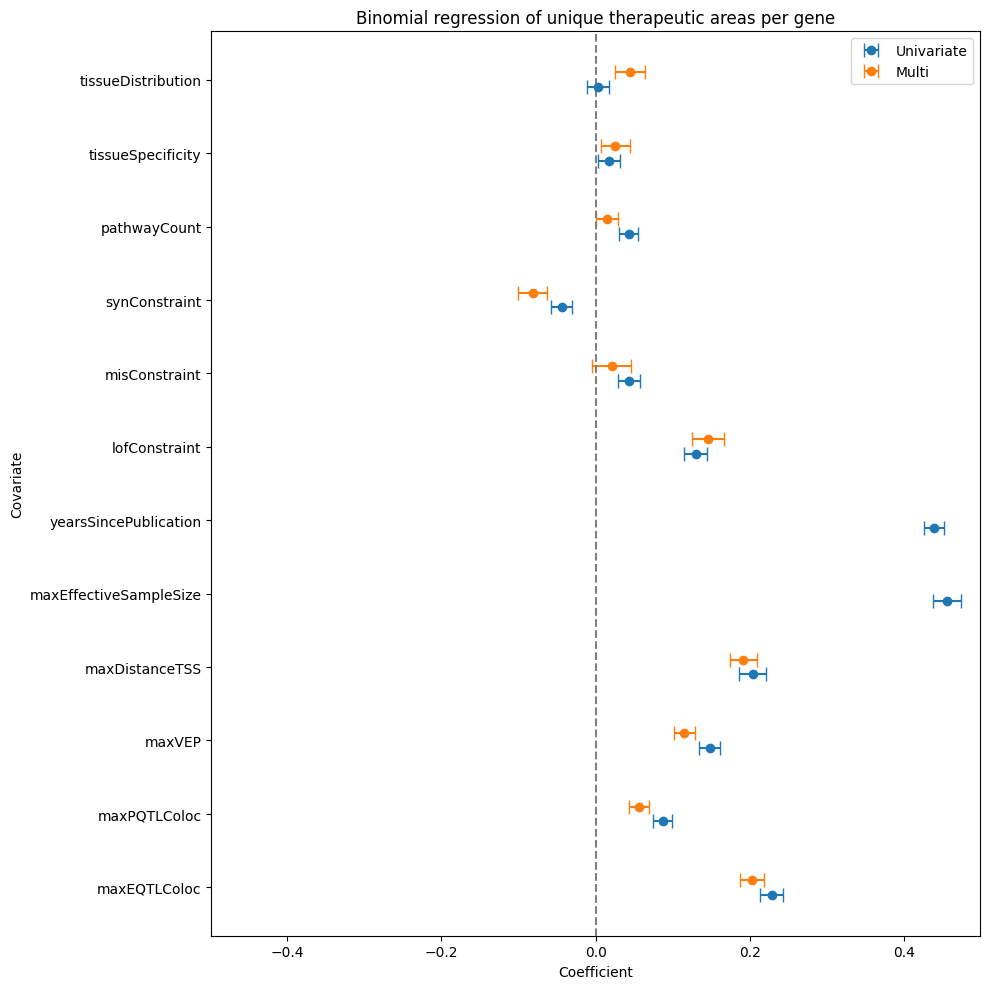

In [13]:
df = genes_pd[
    [
        "geneId",
        "approvedSymbol",
        "uniqueDiseases",
        "uniqueTherapeuticAreas",
        "maxEQTLColoc",
        "maxPQTLColoc",
        "maxVEP",
        "maxDistanceTSS",
        "maxEffectiveSampleSize",
        "earliestPublicationDate",
        "lofConstraint",
        "misConstraint",
        "synConstraint",
        "pathwayCount",
        "tissueSpecificity",
        "tissueDistribution",
    ]
].copy()
df["lofConstraint"] = df["lofConstraint"].fillna(df["lofConstraint"].mean())
df["misConstraint"] = df["misConstraint"].fillna(df["misConstraint"].mean())
df["synConstraint"] = df["synConstraint"].fillna(df["synConstraint"].mean())
df["tissueSpecificity"] = df["tissueSpecificity"].fillna(df["tissueSpecificity"].mean())
df["tissueDistribution"] = df["tissueDistribution"].fillna(df["tissueDistribution"].mean())
df["yearsSincePublication"] = 2025 - pd.to_datetime(df["earliestPublicationDate"], errors="coerce").dt.year

# Standardize covariates
for col in [
    "maxEQTLColoc",
    "maxPQTLColoc",
    "maxVEP",
    "maxDistanceTSS",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "lofConstraint",
    "misConstraint",
    "synConstraint",
    "pathwayCount",
    "tissueSpecificity",
    "tissueDistribution",
]:
    if col in ["maxEffectiveSampleSize"]:
        # Log transform first, then standardize
        log_transformed = np.log(df[col])
        df[col] = (log_transformed - log_transformed.mean()) / log_transformed.std()
    else:
        df[col] = (df[col] - df[col].mean()) / df[col].std()


covariates_univariate = [
    "maxEQTLColoc",
    "maxPQTLColoc",
    "maxVEP",
    "maxDistanceTSS",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "lofConstraint",
    "misConstraint",
    "synConstraint",
    "pathwayCount",
    "tissueSpecificity",
    "tissueDistribution",
]
covariates_multi = [
    "maxEQTLColoc",
    "maxPQTLColoc",
    "maxVEP",
    "maxDistanceTSS",
    # "maxEffectiveSampleSize",
    # "yearsSincePublication",
    "lofConstraint",
    "misConstraint",
    "synConstraint",
    "pathwayCount",
    "tissueSpecificity",
    "tissueDistribution",
]

# Univariate results
univariate_results = []
for covariate in covariates_univariate:
    x_uni = df[[covariate]].copy()
    x_uni = sm.add_constant(x_uni)
    successes_uni = df["uniqueTherapeuticAreas"]
    failures_uni = 23 - successes_uni
    y_uni = np.column_stack((successes_uni, failures_uni))
    model_uni = sm.GLM(y_uni, x_uni, family=sm.families.Binomial()).fit()
    coef = model_uni.params[covariate]
    se = model_uni.bse[covariate]
    pvalue = model_uni.pvalues[covariate]
    ci_lower = model_uni.conf_int().loc[covariate, 0]
    ci_upper = model_uni.conf_int().loc[covariate, 1]
    univariate_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
results_df = pd.DataFrame(univariate_results)
print("Univariate regression results:")
print(results_df.iloc[:, 0:4])

# Multivariate model
x_multi = df[covariates_multi].copy()
x_multi = sm.add_constant(x_multi)
successes_multi = df["uniqueTherapeuticAreas"]
failures_multi = 23 - successes_multi
y_multi = np.column_stack((successes_multi, failures_multi))
model_multi = sm.GLM(y_multi, x_multi, family=sm.families.Binomial()).fit()

# Extract multivariate results for all univariate covariates (fill with NaN if not in model)
multi_results = []
for covariate in covariates_univariate:
    if covariate in covariates_multi:
        coef = model_multi.params[covariate]
        se = model_multi.bse[covariate]
        pvalue = model_multi.pvalues[covariate]
        ci_lower = model_multi.conf_int().loc[covariate, 0]
        ci_upper = model_multi.conf_int().loc[covariate, 1]
    else:
        coef = se = pvalue = ci_lower = ci_upper = np.nan
    multi_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
multi_df = pd.DataFrame(multi_results)
print("Multiple regression results:")
print(multi_df.iloc[:, 0:4])
print("R-squared:", model_multi.pseudo_rsquared())

# Combine univariate and multivariate results for plotting
results_df["model_type"] = "Univariate"
multi_df["model_type"] = "Multi"
combined_results = pd.concat([results_df, multi_df], ignore_index=True)

y_mapping = {cov: i for i, cov in enumerate(covariates_univariate)}
combined_results["y_numerical"] = combined_results["covariate"].map(y_mapping)

offset_val = 0.1
combined_results["y_plot"] = combined_results["y_numerical"] + np.where(
    combined_results["model_type"] == "Univariate", -offset_val, offset_val
)

# Create combined plot with Matplotlib
fig, ax = plt.subplots(figsize=(10, 10))

# Plot univariate results
univariate_data = combined_results[combined_results["model_type"] == "Univariate"]
xerr_uni = [
    univariate_data["coefficient"] - univariate_data["ci_lower"],
    univariate_data["ci_upper"] - univariate_data["coefficient"],
]
ax.errorbar(
    x=univariate_data["coefficient"],
    y=univariate_data["y_plot"],
    xerr=xerr_uni,
    fmt="o",
    label="Univariate",
    capsize=5,
)

# Plot multivariate results
multi_data = combined_results[combined_results["model_type"] == "Multi"]
xerr_multi = [
    multi_data["coefficient"] - multi_data["ci_lower"],
    multi_data["ci_upper"] - multi_data["coefficient"],
]
ax.errorbar(
    x=multi_data["coefficient"],
    y=multi_data["y_plot"],
    xerr=xerr_multi,
    fmt="o",
    label="Multi",
    capsize=5,
)

ax.axvline(x=0, color="gray", linestyle="--")
ax.set_yticks([y_mapping[cov] for cov in covariates_univariate])
ax.set_yticklabels(covariates_univariate, fontsize=10)
ax.set_xlabel("Coefficient")
ax.set_ylabel("Covariate")
ax.set_title("Binomial regression of unique therapeutic areas per gene")
ax.legend()

max_val = np.nanmax(
    np.abs(
        [
            combined_results["coefficient"],
            combined_results["ci_upper"],
            combined_results["ci_lower"],
        ]
    )
)
ax.set_xlim(-max_val - 0.025, max_val + 0.025)
plt.tight_layout()
plt.show()

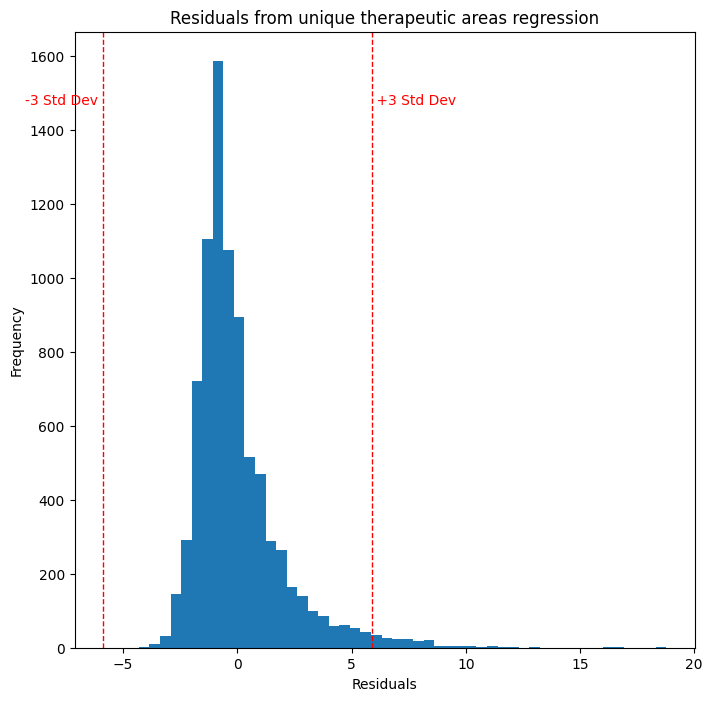

In [14]:
residuals_multi = model_multi.resid_response
std_dev_residuals = np.std(residuals_multi)

plt.figure(figsize=(8, 8))
plt.hist(residuals_multi, bins=50)
plt.title("Residuals from unique therapeutic areas regression")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

# Add vertical lines for standard deviations
plt.axvline(3 * std_dev_residuals, color="r", linestyle="--", linewidth=1)
plt.axvline(-3 * std_dev_residuals, color="r", linestyle="--", linewidth=1)

# Add text annotations for the lines
y_lim = plt.ylim()
plt.text(3 * std_dev_residuals, y_lim[1] * 0.9, " +3 Std Dev", color="r", verticalalignment="top")
plt.text(
    -3 * std_dev_residuals,
    y_lim[1] * 0.9,
    "-3 Std Dev ",
    color="r",
    horizontalalignment="right",
    verticalalignment="top",
)

plt.show()

In [65]:
outliers_below = genes_pd[residuals_multi < -3 * std_dev_residuals]
outliers_above = genes_pd[residuals_multi > 3 * std_dev_residuals]

Univariate regression results:
                 covariate  coefficient  std_error        p_value
0             maxEQTLColoc     0.312666   0.005571   0.000000e+00
1             maxPQTLColoc     0.126859   0.004195  7.658784e-201
2                   maxVEP     0.207662   0.004528   0.000000e+00
3           maxDistanceTSS     0.284834   0.007599  1.641393e-307
4   maxEffectiveSampleSize     0.654017   0.007326   0.000000e+00
5    yearsSincePublication     0.583918   0.004193   0.000000e+00
6            lofConstraint     0.153943   0.005405  2.022002e-178
7            misConstraint     0.044448   0.005214   1.529066e-17
8            synConstraint    -0.063775   0.004870   3.512481e-39
9             pathwayCount     0.060230   0.003432   6.116813e-69
10       tissueSpecificity     0.041574   0.005231   1.898337e-15
11      tissueDistribution     0.021519   0.005192   3.407962e-05
Multiple regression results:
                 covariate  coefficient  std_error       p_value
0             max

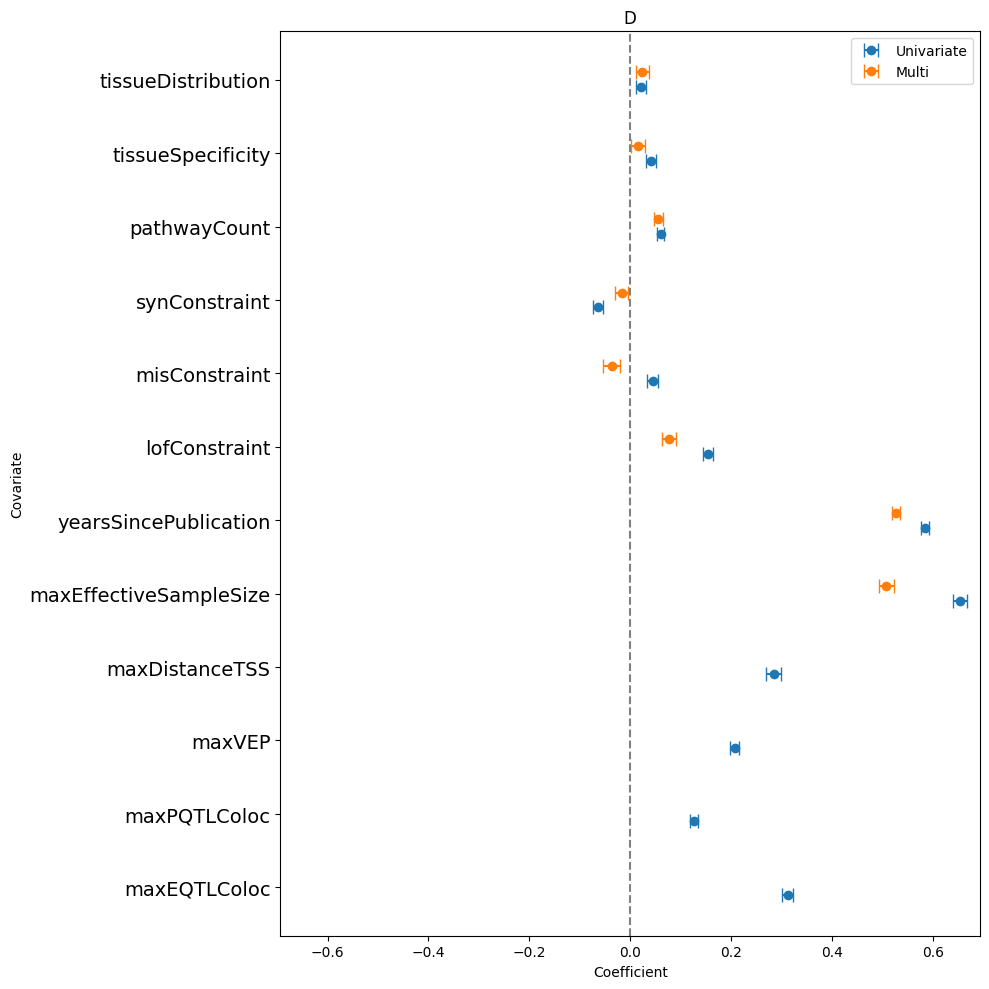

In [15]:
df = genes_pd[
    [
        "geneId",
        "approvedSymbol",
        "uniqueDiseases",
        "uniqueTherapeuticAreas",
        "maxEQTLColoc",
        "maxPQTLColoc",
        "maxVEP",
        "maxDistanceTSS",
        "maxEffectiveSampleSize",
        "earliestPublicationDate",
        "lofConstraint",
        "misConstraint",
        "synConstraint",
        "pathwayCount",
        "tissueSpecificity",
        "tissueDistribution",
    ]
].copy()
df["lofConstraint"] = df["lofConstraint"].fillna(df["lofConstraint"].mean())
df["misConstraint"] = df["misConstraint"].fillna(df["misConstraint"].mean())
df["synConstraint"] = df["synConstraint"].fillna(df["synConstraint"].mean())
df["tissueSpecificity"] = df["tissueSpecificity"].fillna(df["tissueSpecificity"].mean())
df["tissueDistribution"] = df["tissueDistribution"].fillna(df["tissueDistribution"].mean())
df["yearsSincePublication"] = 2025 - pd.to_datetime(df["earliestPublicationDate"], errors="coerce").dt.year

# Standardize covariates
for col in [
    "maxEQTLColoc",
    "maxPQTLColoc",
    "maxVEP",
    "maxDistanceTSS",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "lofConstraint",
    "misConstraint",
    "synConstraint",
    "pathwayCount",
    "tissueSpecificity",
    "tissueDistribution",
]:
    if col in ["maxEffectiveSampleSize"]:
        # Log transform first, then standardize
        log_transformed = np.log(df[col])
        df[col] = (log_transformed - log_transformed.mean()) / log_transformed.std()
    else:
        if df[col].std() > 0:
            df[col] = (df[col] - df[col].mean()) / df[col].std()
        else:
            df[col] = 0


covariates_univariate = [
    "maxEQTLColoc",
    "maxPQTLColoc",
    "maxVEP",
    "maxDistanceTSS",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "lofConstraint",
    "misConstraint",
    "synConstraint",
    "pathwayCount",
    "tissueSpecificity",
    "tissueDistribution",
]
covariates_multi = [
    # "maxEQTLColoc",
    # "maxPQTLColoc",
    # "maxVEP",
    # "maxDistanceTSS",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "lofConstraint",
    "misConstraint",
    "synConstraint",
    "pathwayCount",
    "tissueSpecificity",
    "tissueDistribution",
]

# Univariate results
univariate_results = []
for covariate in covariates_univariate:
    x_uni = df[[covariate]].copy()
    x_uni = sm.add_constant(x_uni)
    y_uni = df["uniqueDiseases"]
    model_uni = sm.GLM(y_uni, x_uni, family=sm.families.Poisson()).fit()
    coef = model_uni.params[covariate]
    se = model_uni.bse[covariate]
    pvalue = model_uni.pvalues[covariate]
    ci_lower = model_uni.conf_int().loc[covariate, 0]
    ci_upper = model_uni.conf_int().loc[covariate, 1]
    univariate_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
results_df = pd.DataFrame(univariate_results)
print("Univariate regression results:")
print(results_df.iloc[:, 0:4])

# Multivariate model
x_multi = df[covariates_multi].copy()
x_multi = sm.add_constant(x_multi)
y_multi = df["uniqueDiseases"]
model_multi = sm.GLM(y_multi, x_multi, family=sm.families.Poisson()).fit()

# Extract multivariate results for all univariate covariates (fill with NaN if not in model)
multi_results = []
for covariate in covariates_univariate:
    if covariate in covariates_multi:
        coef = model_multi.params[covariate]
        se = model_multi.bse[covariate]
        pvalue = model_multi.pvalues[covariate]
        ci_lower = model_multi.conf_int().loc[covariate, 0]
        ci_upper = model_multi.conf_int().loc[covariate, 1]
    else:
        coef = se = pvalue = ci_lower = ci_upper = np.nan
    multi_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
multi_df = pd.DataFrame(multi_results)
print("Multiple regression results:")
print(multi_df.iloc[:, 0:4])
print("R-squared:", model_multi.pseudo_rsquared())

# Combine univariate and multivariate results for plotting
results_df["model_type"] = "Univariate"
multi_df["model_type"] = "Multi"
combined_results = pd.concat([results_df, multi_df], ignore_index=True)

y_mapping = {cov: i for i, cov in enumerate(covariates_univariate)}
combined_results["y_numerical"] = combined_results["covariate"].map(y_mapping)

offset_val = 0.1
combined_results["y_plot"] = combined_results["y_numerical"] + np.where(
    combined_results["model_type"] == "Univariate", -offset_val, offset_val
)

# Create combined plot with Matplotlib
fig, ax = plt.subplots(figsize=(10, 10))

# Plot univariate results
univariate_data = combined_results[combined_results["model_type"] == "Univariate"]
xerr_uni = [
    univariate_data["coefficient"] - univariate_data["ci_lower"],
    univariate_data["ci_upper"] - univariate_data["coefficient"],
]
ax.errorbar(
    x=univariate_data["coefficient"],
    y=univariate_data["y_plot"],
    xerr=xerr_uni,
    fmt="o",
    label="Univariate",
    capsize=5,
)

# Plot multivariate results
multi_data = combined_results[combined_results["model_type"] == "Multi"]
xerr_multi = [
    multi_data["coefficient"] - multi_data["ci_lower"],
    multi_data["ci_upper"] - multi_data["coefficient"],
]
ax.errorbar(
    x=multi_data["coefficient"],
    y=multi_data["y_plot"],
    xerr=xerr_multi,
    fmt="o",
    label="Multi",
    capsize=5,
)

ax.axvline(x=0, color="gray", linestyle="--")
ax.set_yticks([y_mapping[cov] for cov in covariates_univariate])
ax.set_yticklabels(covariates_univariate, fontsize=14)
ax.set_xlabel("Coefficient")
ax.set_ylabel("Covariate")
ax.set_title("D")
ax.legend()

max_val = np.nanmax(
    np.abs(
        [
            combined_results["coefficient"],
            combined_results["ci_upper"],
            combined_results["ci_lower"],
        ]
    )
)
ax.set_xlim(-max_val - 0.025, max_val + 0.025)
plt.tight_layout()
plt.show()

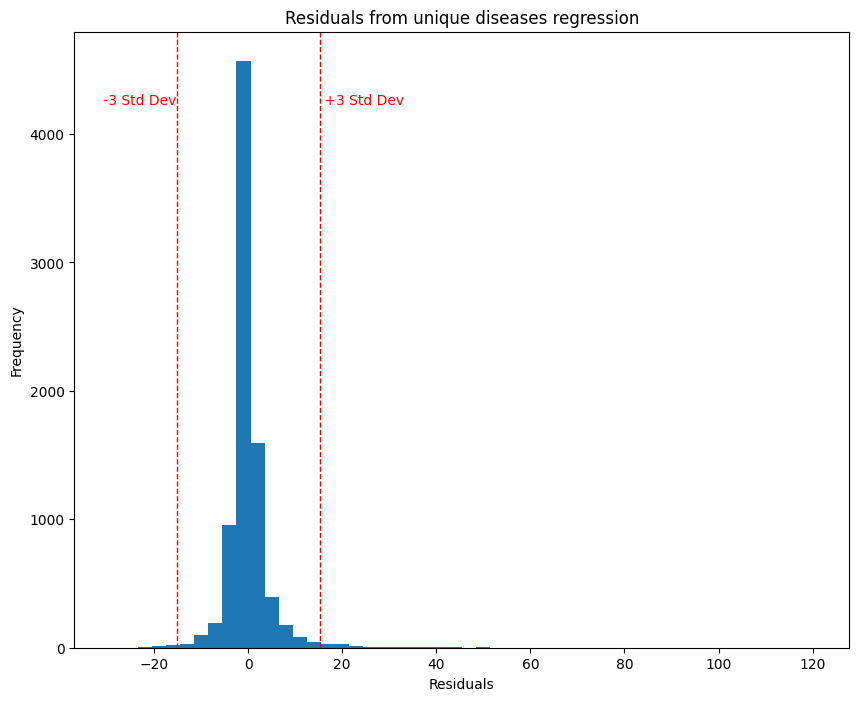

In [18]:
residuals_multi = model_multi.resid_response
std_dev_residuals = np.std(residuals_multi)

plt.figure(figsize=(10, 8))
plt.hist(residuals_multi, bins=50)
plt.title("Residuals from unique diseases regression")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

# Add vertical lines for standard deviations
plt.axvline(3 * std_dev_residuals, color="r", linestyle="--", linewidth=1)
plt.axvline(-3 * std_dev_residuals, color="r", linestyle="--", linewidth=1)

# Add text annotations for the lines
y_lim = plt.ylim()
plt.text(3 * std_dev_residuals, y_lim[1] * 0.9, " +3 Std Dev", color="r", verticalalignment="top")
plt.text(
    -3 * std_dev_residuals,
    y_lim[1] * 0.9,
    " -3 Std Dev",
    color="r",
    horizontalalignment="right",
    verticalalignment="top",
)

plt.show()

In [68]:
outliers_below = genes_pd[residuals_multi < -3 * std_dev_residuals]
outliers_above = genes_pd[residuals_multi > 3 * std_dev_residuals]

# Drug target pleiotropy

In [22]:
drugs = session.spark.read.parquet("gs://open-targets-data-releases/25.06/output/drug_molecule").select(
    "id",
    "blackBoxWarning",
    "isApproved",
    "maximumClinicalTrialPhase",
    "hasBeenWithdrawn",
    f.explode("linkedTargets.rows").alias("linkedTargets"),
)
safety_event_targets = (
    session.spark.read.parquet("/users/dc16/data/releases/25.06/target_prioritisation")
    .select(
        "targetId",
        "hasSafetyEvent",
        "maxClinicalTrialPhase",
        "tissueSpecificity",
        "tissueDistribution",
    )
    .withColumn("hasSafetyEvent", f.when(f.col("hasSafetyEvent") == -1.0, 1).otherwise(0))
    .join(
        drugs.select("linkedTargets"),
        drugs["linkedTargets"] == f.col("targetId"),
        "semi",
    )
    .join(
        genes_therapeutic_areas.select(
            "geneId",
            "uniqueTherapeuticAreas",
            "uniqueDiseases",
            "maxEffectiveSampleSize",
            "earliestPublicationDate",
        ),
        f.col("geneId") == f.col("targetId"),
        "left",
    )
    .drop("geneId")
    .join(
        target.withColumn("pathwayCount", f.size("pathways"))
        .withColumn("pathwayCount", f.when(f.col("pathwayCount") == -1, f.lit(0)).otherwise(f.col("pathwayCount")))
        .withColumns(
            {
                "lofConstraint": f.filter("constraint", lambda x: x.constraintType == "lof")[0]["oeUpper"],
                "misConstraint": f.filter("constraint", lambda x: x.constraintType == "mis")[0]["score"],
                "synConstraint": f.filter("constraint", lambda x: x.constraintType == "syn")[0]["score"],
            }
        )
        .withColumn("lofConstraint", 1 - f.col("lofConstraint"))
        .select(
            f.col("id").alias("geneId"),
            "approvedSymbol",
            "lofConstraint",
            "misConstraint",
            "synConstraint",
            "pathwayCount",
        ),
        f.col("geneId") == f.col("targetId"),
        "left",
    )
    .withColumn(
        "earliestPublicationDate",
        f.when(f.col("earliestPublicationDate").isNull(), "2025-01-01").otherwise(f.col("earliestPublicationDate")),
    )
    .withColumn(
        "maxEffectiveSampleSize",
        f.when(f.col("maxEffectiveSampleSize").isNull(), 0.01).otherwise(f.col("maxEffectiveSampleSize")),
    )
    .drop("geneId")
    .fillna({"uniqueTherapeuticAreas": 0.0})
    .fillna({"uniqueDiseases": 0.0})
    .drop(
        "id",
    )
    .join(
        session.spark.read.parquet(
            "gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/gene_list_fitness_scores.parquet"
        ).select(
            f.col("geneId").alias("targetId"),
            "abs_sum_beta",
            "abs_weighted_sum_beta",
        ),
        "targetId",
        "left",
    )
    .withColumn("abs_sum_beta", f.when(f.col("abs_sum_beta").isNull(), f.lit(0.0)).otherwise(f.col("abs_sum_beta")))
    .withColumn(
        "abs_weighted_sum_beta",
        f.when(f.col("abs_weighted_sum_beta").isNull(), f.lit(0.0)).otherwise(f.col("abs_weighted_sum_beta")),
    )
    .toPandas()
)

In [70]:
safety_event_targets

,targetId,hasSafetyEvent,maxClinicalTrialPhase,tissueSpecificity,tissueDistribution,uniqueTherapeuticAreas,uniqueDiseases,maxEffectiveSampleSize,earliestPublicationDate,approvedSymbol,lofConstraint,misConstraint,synConstraint,pathwayCount,abs_sum_beta,abs_weighted_sum_beta
0,ENSG00000004487,0,0.50,-1.00,-1.0,2,2,235397.698202,2023-01-18,KDM1A,0.362,3.79600,-0.028337,8,0.034074,0.021020
1,ENSG00000005339,0,0.50,-1.00,-1.0,2,3,645988.197508,2015-03-16,CREBBP,0.899,4.77630,-2.984400,53,0.478240,0.242187
2,ENSG00000006116,0,1.00,0.75,0.5,0,0,0.010000,2025-01-01,CACNG3,0.704,3.34030,-0.144570,2,0.000000,0.000000
3,ENSG00000017427,1,0.50,0.50,0.0,5,9,143284.777909,2020-05-13,IGF1,0.325,2.17570,-0.070415,6,1.147986,0.649809
4,ENSG00000019991,1,0.75,1.00,0.0,2,2,521818.707006,2022-11-23,HGF,0.529,1.96280,0.624060,18,1.354099,0.845241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1550,ENSG00000213906,0,0.75,0.50,0.0,0,0,0.010000,2025-01-01,LTB4R2,-0.824,-1.42130,-2.501900,2,0.000000,0.000000
1551,ENSG00000222028,0,1.00,1.00,1.0,0,0,0.010000,2025-01-01,PSMB11,-0.966,0.21383,0.473890,1,0.000000,0.000000
1552,ENSG00000236637,0,0.50,NaN,NaN,0,0,0.010000,2025-01-01,IFNA4,-0.867,-0.44708,-0.207650,6,0.000000,0.000000
1553,ENSG00000263761,0,0.75,1.00,1.0,1,1,358386.300639,2021-11-04,GDF2,-0.208,0.76019,-1.152700,1,0.043056,0.021626


In [71]:
(safety_event_targets["uniqueDiseases"] > 0).sum()

848

In [72]:
safety_event_targets.to_csv("/users/dc16/output/drug_target_safety_events.csv")

In [73]:
(safety_event_targets["hasSafetyEvent"] == 1).sum()

414

Univariate regression results:
                covariate  coefficient  std_error       p_value
0           lofConstraint     0.176713   0.059490  2.973315e-03
1           misConstraint     0.273283   0.057606  2.095185e-06
2           synConstraint     0.117804   0.061413  5.508325e-02
3  uniqueTherapeuticAreas     0.351036   0.054280  9.989087e-11
4          uniqueDiseases     0.315953   0.060832  2.059345e-07
5  maxEffectiveSampleSize     0.290571   0.059014  8.489890e-07
6   yearsSincePublication     0.291622   0.054442  8.484000e-08
7            pathwayCount     0.035693   0.055425  5.195915e-01
8       tissueSpecificity     0.145762   0.058708  1.303435e-02
9      tissueDistribution     0.149673   0.057578  9.337038e-03
Multiple regression results:
                covariate  coefficient  std_error   p_value
0           lofConstraint    -0.042040   0.088314  0.634051
1           misConstraint     0.317503   0.089934  0.000415
2           synConstraint    -0.034717   0.070420  0.622

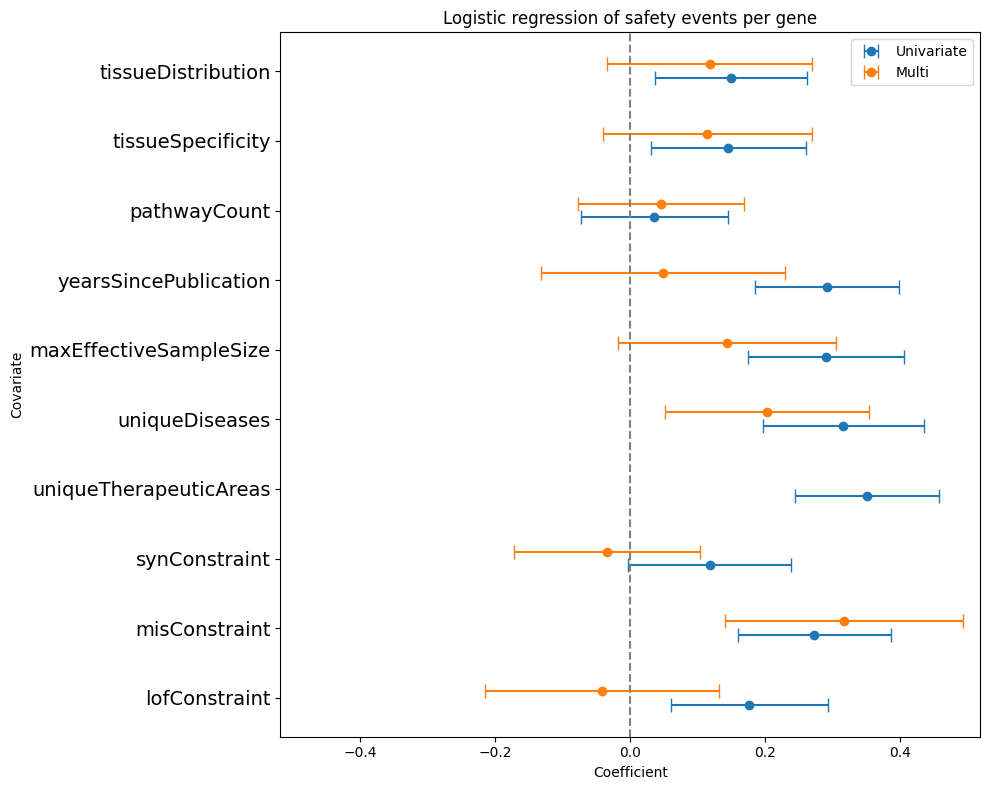

In [23]:
df = safety_event_targets[
    [
        "hasSafetyEvent",
        "lofConstraint",
        "misConstraint",
        "synConstraint",
        "uniqueTherapeuticAreas",
        "uniqueDiseases",
        "maxEffectiveSampleSize",
        "earliestPublicationDate",
        "pathwayCount",
        "abs_sum_beta",
        "abs_weighted_sum_beta",
        "tissueSpecificity",
        "tissueDistribution",
    ]
].copy()
df["lofConstraint"] = df["lofConstraint"].fillna(df["lofConstraint"].mean())
df["misConstraint"] = df["misConstraint"].fillna(df["misConstraint"].mean())
df["synConstraint"] = df["synConstraint"].fillna(df["synConstraint"].mean())
df["tissueSpecificity"] = df["tissueSpecificity"].fillna(df["tissueSpecificity"].mean())
df["tissueDistribution"] = df["tissueDistribution"].fillna(df["tissueDistribution"].mean())
df["yearsSincePublication"] = 2025 - pd.to_datetime(df["earliestPublicationDate"], errors="coerce").dt.year
# Standardize covariates
for col in [
    "lofConstraint",
    "misConstraint",
    "synConstraint",
    "uniqueTherapeuticAreas",
    "uniqueDiseases",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "pathwayCount",
    "abs_sum_beta",
    "abs_weighted_sum_beta",
    "tissueSpecificity",
    "tissueDistribution",
]:
    if col in ["maxEffectiveSampleSize"]:
        # Log transform first, then standardize
        log_transformed = np.log(df[col])
        df[col] = (log_transformed - log_transformed.mean()) / log_transformed.std()
    else:
        df[col] = (df[col] - df[col].mean()) / df[col].std()


covariates_univariate = [
    "lofConstraint",
    "misConstraint",
    "synConstraint",
    "uniqueTherapeuticAreas",
    "uniqueDiseases",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "pathwayCount",
    # 'abs_sum_beta',
    # 'abs_weighted_sum_beta',
    "tissueSpecificity",
    "tissueDistribution",
]
covariates_multi = [
    "lofConstraint",
    "misConstraint",
    "synConstraint",
    # "uniqueTherapeuticAreas",
    "uniqueDiseases",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "pathwayCount",
    # 'abs_sum_beta',
    # 'abs_weighted_sum_beta',
    "tissueSpecificity",
    "tissueDistribution",
]

# Univariate results
univariate_results = []
for covariate in covariates_univariate:
    x_uni = df[[covariate]].copy()
    x_uni = sm.add_constant(x_uni)
    y_uni = df["hasSafetyEvent"]
    model_uni = sm.GLM(y_uni, x_uni, family=sm.families.Binomial()).fit()
    coef = model_uni.params[covariate]
    se = model_uni.bse[covariate]
    pvalue = model_uni.pvalues[covariate]
    ci_lower = model_uni.conf_int().loc[covariate, 0]
    ci_upper = model_uni.conf_int().loc[covariate, 1]
    univariate_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
results_df = pd.DataFrame(univariate_results)
print("Univariate regression results:")
print(results_df.iloc[:, 0:4])

# Multivariate model
x_multi = df[covariates_multi].copy()
x_multi = sm.add_constant(x_multi)
y_multi = df["hasSafetyEvent"]
model_multi = sm.GLM(y_multi, x_multi, family=sm.families.Binomial()).fit()

# Extract multivariate results for all univariate covariates (fill with NaN if not in model)
multi_results = []
for covariate in covariates_univariate:
    if covariate in covariates_multi:
        coef = model_multi.params[covariate]
        se = model_multi.bse[covariate]
        pvalue = model_multi.pvalues[covariate]
        ci_lower = model_multi.conf_int().loc[covariate, 0]
        ci_upper = model_multi.conf_int().loc[covariate, 1]
    else:
        coef = se = pvalue = ci_lower = ci_upper = np.nan
    multi_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
multi_df = pd.DataFrame(multi_results)
print("Multiple regression results:")
print(multi_df.iloc[:, 0:4])
print("R-squared:", model_multi.pseudo_rsquared())

# Combine univariate and multivariate results for plotting
results_df["model_type"] = "Univariate"
multi_df["model_type"] = "Multi"
combined_results = pd.concat([results_df, multi_df], ignore_index=True)

y_mapping = {cov: i for i, cov in enumerate(covariates_univariate)}
combined_results["y_numerical"] = combined_results["covariate"].map(y_mapping)

offset_val = 0.1
combined_results["y_plot"] = combined_results["y_numerical"] + np.where(
    combined_results["model_type"] == "Univariate", -offset_val, offset_val
)

# Create combined plot with Matplotlib
fig, ax = plt.subplots(figsize=(10, 8))

# Plot univariate results
univariate_data = combined_results[combined_results["model_type"] == "Univariate"]
xerr_uni = [
    univariate_data["coefficient"] - univariate_data["ci_lower"],
    univariate_data["ci_upper"] - univariate_data["coefficient"],
]
ax.errorbar(
    x=univariate_data["coefficient"],
    y=univariate_data["y_plot"],
    xerr=xerr_uni,
    fmt="o",
    label="Univariate",
    capsize=5,
)

# Plot multivariate results
multi_data = combined_results[combined_results["model_type"] == "Multi"]
xerr_multi = [
    multi_data["coefficient"] - multi_data["ci_lower"],
    multi_data["ci_upper"] - multi_data["coefficient"],
]
ax.errorbar(
    x=multi_data["coefficient"],
    y=multi_data["y_plot"],
    xerr=xerr_multi,
    fmt="o",
    label="Multi",
    capsize=5,
)

ax.axvline(x=0, color="gray", linestyle="--")
ax.set_yticks([y_mapping[cov] for cov in covariates_univariate])
ax.set_yticklabels(covariates_univariate, fontsize=14)
ax.set_xlabel("Coefficient")
ax.set_ylabel("Covariate")
ax.set_title("Logistic regression of safety events per gene")
ax.legend()

max_val = np.nanmax(
    np.abs(
        [
            combined_results["coefficient"],
            combined_results["ci_upper"],
            combined_results["ci_lower"],
        ]
    )
)
ax.set_xlim(-max_val - 0.025, max_val + 0.025)
plt.tight_layout()
plt.show()

In [75]:
(safety_event_targets["maxClinicalTrialPhase"] > 0.5).sum()

1224

In [76]:
df = genes_therapeutic_areas.toPandas()
df["lofConstraint"] = df["lofConstraint"].fillna(df["lofConstraint"].mean())
df["misConstraint"] = df["misConstraint"].fillna(df["misConstraint"].mean())
df["synConstraint"] = df["synConstraint"].fillna(df["synConstraint"].mean())
df["yearsSincePublication"] = 2025 - pd.to_datetime(df["earliestPublicationDate"], errors="coerce").dt.year
for col in covariates_multi:
    if col in ["minEffectiveSampleSize", "maxEffectiveSampleSize"]:
        # Log transform first, then standardize
        log_transformed = np.log(df[col])
        df[col] = (log_transformed - log_transformed.mean()) / log_transformed.std()
    else:
        df[col] = (df[col] - df[col].mean()) / df[col].std()
x_new = sm.add_constant(df[covariates_multi])
predicted_probs = model_multi.predict(x_new)
df["predicted_safety_event_prob"] = predicted_probs
safety_events_pd = (
    session.spark.read.parquet("/users/dc16/data/releases/25.06/target_prioritisation")
    .select(
        "targetId",
        "hasSafetyEvent",
    )
    .withColumn("hasSafetyEvent", f.when(f.col("hasSafetyEvent") == -1, 1).otherwise(0))
    .toPandas()
)
df = pd.merge(df, safety_events_pd, left_on="geneId", right_on="targetId", how="left").drop(columns=["targetId"])

In [77]:
df

,geneId,uniqueDiseases,uniqueTherapeuticAreas,maxEQTLColoc,maxPQTLColoc,maxVEP,maxDistanceTSS,minEffectiveSampleSize,maxEffectiveSampleSize,earliestPublicationDate,...,approvedSymbol,lofConstraint,misConstraint,synConstraint,pathwayCount,tissueSpecificity,tissueDistribution,yearsSincePublication,predicted_safety_event_prob,hasSafetyEvent
0,ENSG00000147883,21.634413,21,1,0,0,1,1622.261017,1.200655,2007-04-26,...,CDKN2B,-2.138460e+00,-1.228016,-0.043828,0.361604,0.668276,0.562125,3.066602,0.970958,0
1,ENSG00000175164,15.153941,20,1,1,1,1,1249.622344,1.200655,2009-03-10,...,ABO,-1.178010e+00,-0.464632,-0.125723,-0.399586,0.668276,0.562125,2.581318,0.912207,1
2,ENSG00000140718,18.318823,19,1,0,0,1,1059.622642,1.222597,2007-04-26,...,FTO,-5.291176e-02,0.169123,0.953355,-0.247348,-1.127330,-0.982742,3.066602,0.939702,1
3,ENSG00000111252,12.441185,17,1,1,1,1,5504.013052,0.766224,2009-05-10,...,SH2B3,-1.027082e+00,-2.323691,-1.534523,0.057128,0.668276,-0.982742,2.581318,0.734950,0
4,ENSG00000130203,15.455358,16,1,1,1,1,613.779310,1.353258,2013-04-04,...,APOE,-9.561920e-01,-1.182796,-0.649547,1.427270,0.967544,-0.982742,1.610750,0.890345,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8280,ENSG00000288867,-0.519758,1,0,0,0,1,155496.871408,-0.128809,2025-04-01,...,PPIAL4C,-2.136173e+00,0.138695,1.060983,-0.399586,0.668276,1.334558,-1.300953,0.281490,0
8281,ENSG00000289710,-0.519758,1,0,0,0,1,286746.100275,0.384509,2024-06-05,...,ENSG00000289710,1.703788e-08,0.000000,0.000000,-0.399586,NaN,NaN,-1.058311,NaN,0
8282,ENSG00000291315,-0.519758,1,0,0,0,0,376569.559706,0.287268,2023-01-18,...,ENSG00000291315,1.703788e-08,0.000000,0.000000,-0.399586,1.266812,1.334558,-0.815669,0.292686,0
8283,ENSG00000293137,-0.519758,1,0,0,0,0,292977.180692,0.114922,2021-11-04,...,MSL3B,1.703788e-08,0.000000,0.000000,-0.399586,NaN,NaN,-0.330386,NaN,0


In [78]:
high_predicted_no_event = df[(df["predicted_safety_event_prob"] > 0.5) & (df["hasSafetyEvent"] == 0)]
low_predicted_event = df[(df["predicted_safety_event_prob"] < 0.5) & (df["hasSafetyEvent"] == 1)]

In [79]:
high_predicted_no_event.to_csv("/users/dc16/output/gentropy_paper/high_predicted_no_safety_event.csv")
high_predicted_no_event.sort_values("predicted_safety_event_prob", ascending=False)

,geneId,uniqueDiseases,uniqueTherapeuticAreas,maxEQTLColoc,maxPQTLColoc,maxVEP,maxDistanceTSS,minEffectiveSampleSize,maxEffectiveSampleSize,earliestPublicationDate,...,approvedSymbol,lofConstraint,misConstraint,synConstraint,pathwayCount,tissueSpecificity,tissueDistribution,yearsSincePublication,predicted_safety_event_prob,hasSafetyEvent
0,ENSG00000147883,21.634413,21,1,0,0,1,1622.261017,1.200655,2007-04-26,...,CDKN2B,-2.138460,-1.228016,-0.043828,0.361604,0.668276,0.562125,3.066602,0.970958,0
5,ENSG00000166949,11.687642,16,1,0,1,1,6762.688255,1.222597,2010-09-23,...,SMAD3,1.207107,1.906421,0.054880,2.949651,-1.127330,-0.982742,2.338676,0.885303,0
73,ENSG00000123384,3.549375,11,1,0,0,1,1458.170321,0.431940,2011-06-12,...,LRP1,1.790237,6.224047,2.816384,-0.095110,0.668276,-0.982742,2.096034,0.829487,0
9,ENSG00000134242,10.029847,15,1,0,1,0,937.714818,0.434505,2007-06-06,...,PTPN22,-0.098647,0.148932,0.155921,-0.095110,0.668276,0.562125,3.066602,0.797238,0
20,ENSG00000137265,8.673469,13,1,0,1,1,1494.987133,0.380417,2008-08-31,...,IRF4,1.184239,1.093481,0.017248,0.361604,0.668276,0.562125,2.823960,0.793530,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,ENSG00000173531,3.398666,11,1,1,1,1,2303.867283,1.222597,2008-06-29,...,MST1,-0.114655,0.304219,0.740471,-0.247348,1.266812,-0.982742,2.823960,0.508558,0
723,ENSG00000073282,1.740871,5,1,0,1,1,2201.750199,0.380417,2010-09-26,...,TP63,1.383190,1.433640,0.393575,0.970556,0.668276,0.562125,2.338676,0.507801,0
311,ENSG00000166033,4.001501,8,1,0,1,1,1116.190214,0.346742,2010-04-12,...,HTRA1,0.063714,-0.156497,-0.827512,-0.247348,0.668276,0.562125,2.338676,0.505365,0
1253,ENSG00000168959,0.987328,4,0,0,0,1,2271.227834,1.037302,2018-04-16,...,GRM5,1.076760,1.316429,-1.063536,0.057128,1.266812,1.334558,0.397540,0.505234,0


In [80]:
low_predicted_event.to_csv("/users/dc16/output/gentropy_paper/low_predicted_safety_event.csv")
low_predicted_event.sort_values("predicted_safety_event_prob", ascending=True)

,geneId,uniqueDiseases,uniqueTherapeuticAreas,maxEQTLColoc,maxPQTLColoc,maxVEP,maxDistanceTSS,minEffectiveSampleSize,maxEffectiveSampleSize,earliestPublicationDate,...,approvedSymbol,lofConstraint,misConstraint,synConstraint,pathwayCount,tissueSpecificity,tissueDistribution,yearsSincePublication,predicted_safety_event_prob,hasSafetyEvent
1463,ENSG00000186153,-0.067632,4,1,0,0,1,31303.173087,0.249549,2019-09-01,...,WWOX,-2.101871,-3.732922,-4.089783,0.057128,-1.127330,-0.982742,0.154898,0.097209,1
7238,ENSG00000136159,-0.369050,1,0,0,1,1,658.045902,-4.072451,2018-06-19,...,NUDT15,-1.059097,-0.875877,-0.588540,-0.095110,-1.127330,-0.982742,0.397540,0.103126,1
6565,ENSG00000025708,-0.519758,1,1,1,0,0,112184.220472,-0.544196,2024-04-26,...,TYMP,-1.411262,-2.478753,-1.830349,-0.095110,-1.127330,0.562125,-1.058311,0.116313,1
7005,ENSG00000117525,-0.519758,1,0,0,0,1,6356.593452,-2.515227,2023-05-29,...,F3,0.141465,-0.483321,-0.157133,-0.095110,-1.127330,-0.982742,-0.815669,0.122354,1
6185,ENSG00000164300,-0.519758,1,0,0,0,1,5239.920684,-2.647871,2024-07-19,...,SERINC5,-0.023184,-0.171565,-0.038704,-0.247348,-1.127330,-0.982742,-1.058311,0.129379,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,ENSG00000198822,1.138037,4,1,0,0,1,606.666667,0.644017,2014-07-22,...,GRM3,0.932693,1.278465,0.447215,-0.095110,1.266812,1.334558,1.368108,0.494257,1
830,ENSG00000112541,0.685911,5,1,0,0,1,7098.679737,1.200655,2016-05-16,...,PDE10A,1.083621,1.725543,0.604685,-0.095110,1.266812,0.562125,0.882824,0.495150,1
5606,ENSG00000273079,-0.519758,1,0,0,0,1,7794.273577,-2.375228,2021-03-01,...,GRIN2B,1.826826,3.583089,0.166731,1.275032,1.266812,2.106991,-0.330386,0.495803,1
270,ENSG00000169684,4.001501,8,1,0,1,1,3627.294470,0.344385,2008-04-03,...,CHRNA5,-0.121515,0.424974,0.642325,-0.095110,-1.127330,0.562125,2.823960,0.497056,1
